In [1]:
# ====================================================================
# CELL 1: Environment Setup and Library Imports
# ====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from wordcloud import WordCloud

# Text processing
import re
import string
from collections import Counter
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, GRU, SimpleRNN, Bidirectional, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Word embeddings
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence

# Set random seeds for reproducibility
import random
import os
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'

# Display settings
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")

2025-09-05 22:37:30.599538: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757111850.817655      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757111850.880377      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


All libraries imported successfully!
TensorFlow version: 2.18.0
Pandas version: 2.2.3


In [2]:
# ====================================================================
# CELL 2: Data Loading and Initial Exploration

train_df = pd.read_csv('/kaggle/input/cse440-ds/train.csv')  
test_df = pd.read_csv('/kaggle/input/cse440-ds/test.csv')   

print("Shape of the dataset - ")
print()
print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}")
print()
print("----------------------------------")
print()
print("Top 5 rows of the dataset -")
print(train_df.head())
print()
print("----------------------------------")
print("Bottom 5 rows of the dataset -")
print(train_df.tail(5))
print("----------------------------------")
print()
print("Data Types:")
print()
print(train_df.dtypes)
print()
print("----------------------------------")
print()
print("Missing Values:")
print()
print(train_df.isnull().sum())
print()
print("----------------------------------")

unique_questions = train_df['QA Text'].nunique()

# Check for duplicates in the QA Text column
duplicates = train_df['QA Text'].duplicated().sum()

# Display the number of unique questions and duplicated questions
print(f"Number of unique questions: {unique_questions}")
print(f"Number of duplicated questions: {duplicates}")


print("Frequency distribution of 'Class' column (sorted from lowest to highest):")
print()
print(train_df['Class'].value_counts().sort_values(ascending=True))

Shape of the dataset - 

Training set shape: (280003, 2)
Testing set shape: (59999, 2)

----------------------------------

Top 5 rows of the dataset -
                                             QA Text                  Class
0  Question Title:\ni am good at web design amate...     Business & Finance
1  Question Title:\nMy daughter wants to be a Med...  Education & Reference
2  Question Title:\nIs brother Jesus our brother ...      Society & Culture
3  Question Title:\nwhat is I-20?\nQuestion Conte...  Education & Reference
4  Question Title:\nwhat is a data disk?\nQuestio...   Computers & Internet

----------------------------------
Bottom 5 rows of the dataset -
                                                  QA Text  \
279998  Question Title:\nWhat is the best way to learn...   
279999  Question Title:\nWhat is the current payroll o...   
280000  Question Title:\nWhat's your opinion on the ba...   
280001  Question Title:\nWhat do you think will happen...   
280002  Question Tit

# Distribution of Number of QA Texts Across Classes

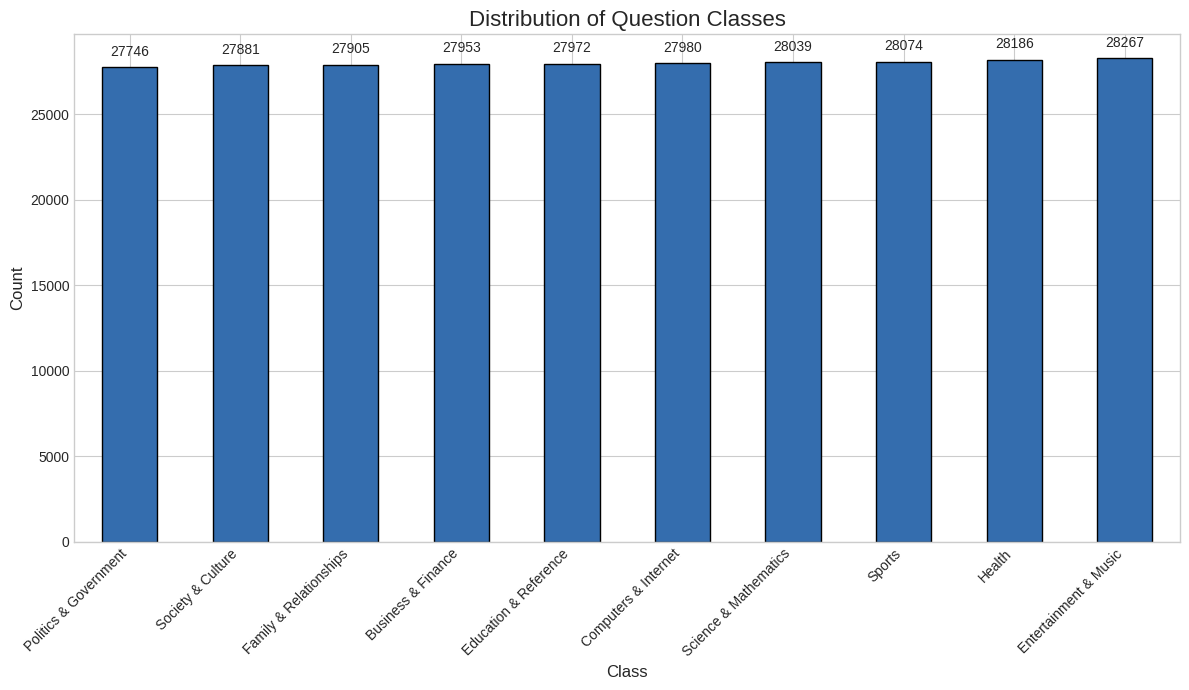

In [3]:
plt.style.use('seaborn-v0_8-whitegrid') # Using seaborn style for better aesthetics

class_counts = train_df['Class'].value_counts().sort_values(ascending=True) # Sort counts

plt.figure(figsize=(12, 7)) # Increased figure size for better readability
bars = class_counts.plot(kind='bar', color='#346DAE', edgecolor='black') # Using a single blue color

plt.title("Distribution of Question Classes", fontsize=16) # More descriptive title
plt.xlabel("Class", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels and align to the right
plt.yticks(fontsize=10)


# Add the exact number on top of each bar
for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, yval, ha='center', va='bottom', fontsize=10) # Adjusted vertical offset and font size

plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

Average QA Text Length for Each Class:

Entertainment & Music: 428.00 words
Sports: 441.03 words
Business & Finance: 520.33 words
Computers & Internet: 523.18 words
Education & Reference: 548.27 words
Family & Relationships: 587.76 words
Science & Mathematics: 634.05 words
Health: 653.18 words
Society & Culture: 660.03 words
Politics & Government: 670.09 words


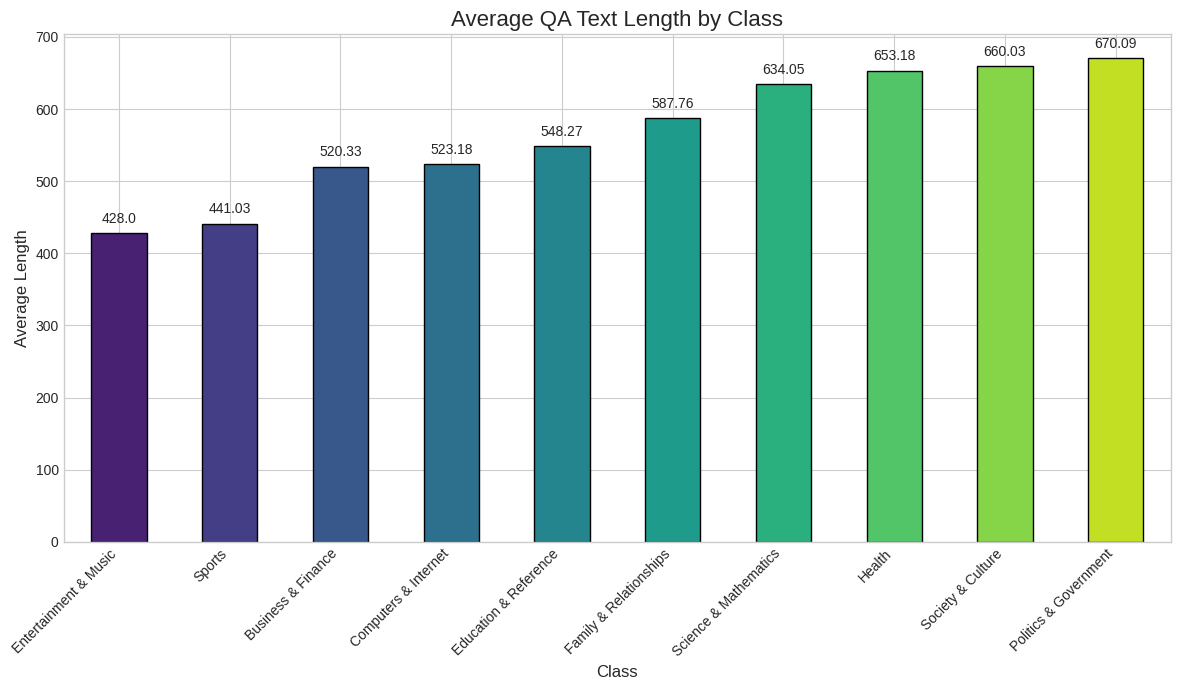

In [4]:
# Calculate the length of 'QA Text' for each row
train_df['QA Text Length'] = train_df['QA Text'].apply(len)

# Calculate the average 'QA Text Length' for each 'Class'
average_text_length_by_class = train_df.groupby('Class')['QA Text Length'].mean().sort_values(ascending=True)

# Display the results
print("Average QA Text Length for Each Class:\n")
for class_name, avg_length in average_text_length_by_class.items():
    print(f"{class_name}: {avg_length:.2f} words")


plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(12, 7))
bars = average_text_length_by_class.plot(kind='bar', color=sns.color_palette("viridis", len(average_text_length_by_class)), edgecolor='black')

plt.title("Average QA Text Length by Class", fontsize=16)
plt.xlabel("Class", fontsize=12)
plt.ylabel("Average Length", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(fontsize=10)

# Add the exact number on top of each bar
for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, round(yval, 2), ha='center', va='bottom', fontsize=10) # Display rounded average length

plt.tight_layout()
plt.show()

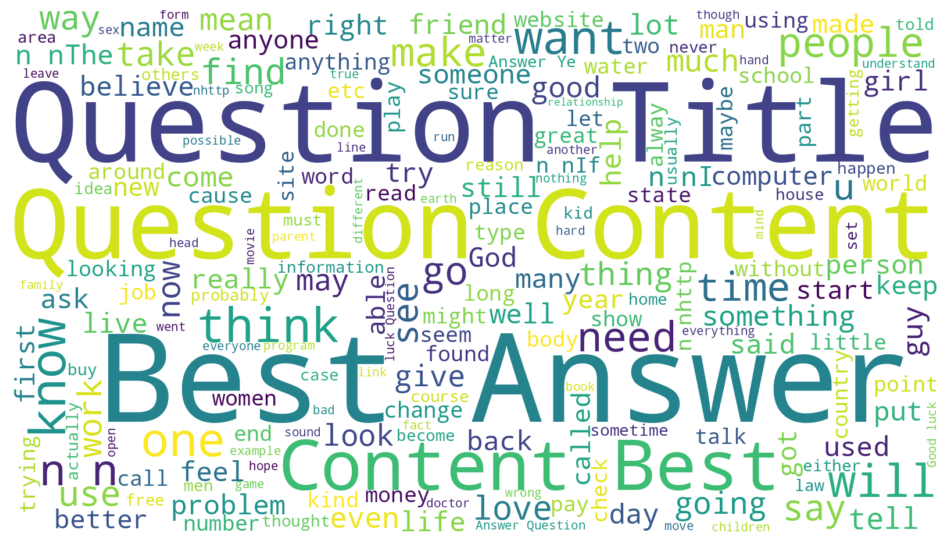

In [5]:
text = " ".join(train_df["QA Text"].astype(str))
wordcloud = WordCloud(width=1600, height=900, background_color='white').generate(text)
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


In [6]:
# Define stopwords
stop_words = list(stopwords.words('english'))
stop_words.append("question")
stop_words.append("title")
stop_words.append("content")
stop_words.append("best")
stop_words.append("answer")
print(stop_words)

# Define punctuation list
punctuations = list(string.punctuation)
print(punctuations)
train_df.head(5)
check_df = train_df.head(20).copy()
check_df

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

,QA Text,Class,QA Text Length
0,Question Title:\ni am good at web design amate...,Business & Finance,452
1,Question Title:\nMy daughter wants to be a Med...,Education & Reference,1901
2,Question Title:\nIs brother Jesus our brother ...,Society & Culture,161
3,Question Title:\nwhat is I-20?\nQuestion Conte...,Education & Reference,359
4,Question Title:\nwhat is a data disk?\nQuestio...,Computers & Internet,496
5,Question Title:\nDon't you think that all thos...,Entertainment & Music,119
6,Question Title:\nwhy do people have all the se...,Society & Culture,842
7,Question Title:\nWho is the oldest golfer to h...,Sports,135
8,Question Title:\nwhat is a loan guarantor? (on...,Business & Finance,183
9,Question Title:\nwhat is the meaning of Magi c...,Education & Reference,125


# Preprocessing

In [7]:
# ================================================================
# Preprocessing 
# ================================================================

import re
import os
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize stopwords + lemmatizer
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(raw_text):
    # Step 1: Remove unwanted prefixes
    raw_text = re.sub(r"(?i)(Question Title:|Question Content:|Best Answer:)\s*", "", raw_text)

    # Step 2: Replace literal "\n" with space and remove real line breaks
    raw_text = raw_text.replace("\\n", " ").replace("\n", " ")

    # Step 3: Normalize spaces
    raw_text = re.sub(r"\s+", " ", raw_text).strip()

    # Step 4: Lowercase
    raw_text = raw_text.lower()

    # Step 5: Tokenize words
    words = raw_text.split()

    # Step 6: Remove stopwords + lemmatize + clean punctuation
    cleaned_words = []
    for word in words:
        if word not in stop_words:
            # Preserve URLs / domains
            if re.match(r"^www\.[a-zA-Z0-9\-\.]+$", word) or re.match(r"\w+\.(html|com|org|net|edu|gov|co|io|tv)$", word):
                cleaned_words.append(word)
            else:
                # Remove punctuation
                word = re.sub(r"[^\w\s]", "", word).strip()
                if word:
                    # Lemmatize
                    cleaned_words.append(lemmatizer.lemmatize(word))

    # Step 7: Join words back
    cleaned_text = " ".join(cleaned_words)
    return cleaned_text

# ================================================================
# Apply cleaning to datasets
# ================================================================

# Clean check_df
check_df['Cleaned QA Text'] = check_df['QA Text'].apply(clean_text)
print(check_df[['QA Text', 'Cleaned QA Text']])

check_df.to_csv('cleaned_data.csv', index=False)
print("✅ check_df saved to cleaned_data.csv")

# Clean train/test
train_df['Cleaned QA Text'] = train_df['QA Text'].apply(clean_text)
test_df['Cleaned QA Text'] = test_df['QA Text'].apply(clean_text)
print("✅ Cleaning applied to train and test data.")

# Save cleaned train/test into Kaggle working directory
save_path = '/kaggle/working/cleaned_data_checkpoint'
os.makedirs(save_path, exist_ok=True)

train_df.to_csv(os.path.join(save_path, 'cleaned_train.csv'), index=False)
test_df.to_csv(os.path.join(save_path, 'cleaned_test.csv'), index=False)

print(f"✅ Cleaned train and test data saved to {save_path}")


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                              QA Text  \
0   Question Title:\ni am good at web design amate...   
1   Question Title:\nMy daughter wants to be a Med...   
2   Question Title:\nIs brother Jesus our brother ...   
3   Question Title:\nwhat is I-20?\nQuestion Conte...   
4   Question Title:\nwhat is a data disk?\nQuestio...   
5   Question Title:\nDon't you think that all thos...   
6   Question Title:\nwhy do people have all the se...   
7   Question Title:\nWho is the oldest golfer to h...   
8   Question Title:\nwhat is a loan guarantor? (on...   
9   Question Title:\nwhat is the meaning of Magi c...   
10  Question Title:\nhello viewers i need an answe...   
11  Question Title:\nhow do i tell her i love her?...   
12  Question Title:\nI want employment at UN Organ...   
13  Question Title:\nhow can u crack a secured wir...   
14  Question Title:\nMy throat goes wrong?\nQuesti...   
15  Question Title:\nShould Michelle Wie drop golf...   
16  Question Title:\ncan you he

# Load Dataset

In [8]:
import os
import pandas as pd

# Path to where you saved your cleaned CSVs inside Kaggle (working dir)
save_path = '/kaggle/working/cleaned_data_checkpoint'

# File names
train_filename_cleaned = 'cleaned_train.csv'
test_filename_cleaned = 'cleaned_test.csv'

# Construct full file paths
train_filepath_cleaned = os.path.join(save_path, train_filename_cleaned)
test_filepath_cleaned = os.path.join(save_path, test_filename_cleaned)

# Load the cleaned training data
train_df_cleaned = pd.read_csv(train_filepath_cleaned)

# Load the cleaned testing data
test_df_cleaned = pd.read_csv(test_filepath_cleaned)

'''# Display the first 5 rows of both DataFrames
print("First 5 rows of cleaned training data:")
display(train_df_cleaned.head())

print("\nFirst 5 rows of cleaned testing data:")
display(test_df_cleaned.head())'''


'# Display the first 5 rows of both DataFrames\nprint("First 5 rows of cleaned training data:")\ndisplay(train_df_cleaned.head())\n\nprint("\nFirst 5 rows of cleaned testing data:")\ndisplay(test_df_cleaned.head())'

# Implement Bag of Words vectorization on the cleaned text data.

In [9]:
# Instantiate CountVectorizer
# Set max_features to limit the vocabulary size
vectorizer = CountVectorizer(max_features=10000) # Example limit, can be adjusted

# Fit the vectorizer on the 'Cleaned QA Text' column of the training DataFrame
vectorizer.fit(train_df_cleaned['Cleaned QA Text'])

# Transform the 'Cleaned QA Text' column of the training DataFrame
X_train_bow = vectorizer.transform(train_df_cleaned['Cleaned QA Text'])

# Transform the 'Cleaned QA Text' column of the testing DataFrame
X_test_bow = vectorizer.transform(test_df_cleaned['Cleaned QA Text'])

# Print the shape of the resulting BoW matrices
print("Shape of training BoW matrix:", X_train_bow.shape)
print("Shape of testing BoW matrix:", X_test_bow.shape)

Shape of training BoW matrix: (280003, 10000)
Shape of testing BoW matrix: (59999, 10000)


# TF-IDF

In [10]:

tfidf_vectorizer = TfidfVectorizer(max_features=10000) # Example limit, can be adjusted

# Fit the vectorizer on the 'Cleaned QA Text' column of the training DataFrame
tfidf_vectorizer.fit(train_df_cleaned['Cleaned QA Text'])

# Transform the 'Cleaned QA Text' column of the training DataFrame
X_train_tfidf = tfidf_vectorizer.transform(train_df_cleaned['Cleaned QA Text'])

# Transform the 'Cleaned QA Text' column of the testing DataFrame using the same fitted vectorizer
X_test_tfidf = tfidf_vectorizer.transform(test_df_cleaned['Cleaned QA Text'])

# Print the shapes of the resulting TF-IDF matrices to verify the outcome
print("Shape of training TF-IDF matrix:", X_train_tfidf.shape)
print("Shape of testing TF-IDF matrix:", X_test_tfidf.shape)

Shape of training TF-IDF matrix: (280003, 10000)
Shape of testing TF-IDF matrix: (59999, 10000)


# Random Forest BoW Feature

In [11]:
# Instantiate CountVectorizer
# Set max_features to limit the vocabulary size
vectorizer = CountVectorizer(max_features=10000) # Example limit, can be adjusted

# Fit the vectorizer on the 'Cleaned QA Text' column of the training DataFrame
vectorizer.fit(train_df_cleaned['Cleaned QA Text'])

# Transform the 'Cleaned QA Text' column of the training DataFrame
X_train_bow = vectorizer.transform(train_df_cleaned['Cleaned QA Text'])

# Transform the 'Cleaned QA Text' column of the testing DataFrame
X_test_bow = vectorizer.transform(test_df_cleaned['Cleaned QA Text'])

# Print the shape of the resulting BoW matrices
print("Shape of training BoW matrix:", X_train_bow.shape)
print("Shape of testing BoW matrix:", X_test_bow.shape)

# Ensure y_train / y_test exist (fall back to Class column if needed)
if 'y_train' not in globals():
    print("y_train not found — creating from train_df_cleaned['Class'].")
    y_train = train_df_cleaned['Class']
if 'y_test' not in globals():
    print("y_test not found — creating from test_df_cleaned['Class'].")
    y_test = test_df_cleaned['Class']


# Now, train and tune Random Forest with BoW
print("\nTraining Random Forest with BoW features...")
rf_bow = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [50, 100], # Reduced for faster tuning
    'max_depth': [10, 20], # Reduced for faster tuning
    'min_samples_split': [2, 5]
}
grid_search_rf_bow = GridSearchCV(rf_bow, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_rf_bow.fit(X_train_bow, y_train)

print("Best parameters for Random Forest (BoW):", grid_search_rf_bow.best_params_)

y_pred_rf_bow = grid_search_rf_bow.predict(X_test_bow)
print("Accuracy (Random Forest with BoW):", accuracy_score(y_test, y_pred_rf_bow))
print("Classification Report (Random Forest with BoW):\n", classification_report(y_test, y_pred_rf_bow))

# Store results
rf_bow_results = {
    'model': 'Random Forest',
    'features': 'BoW',
    'best_params': grid_search_rf_bow.best_params_,
    'accuracy': accuracy_score(y_test, y_pred_rf_bow),
    'report': classification_report(y_test, y_pred_rf_bow, output_dict=True)
}

Shape of training BoW matrix: (280003, 10000)
Shape of testing BoW matrix: (59999, 10000)
y_train not found — creating from train_df_cleaned['Class'].
y_test not found — creating from test_df_cleaned['Class'].

Training Random Forest with BoW features...
Best parameters for Random Forest (BoW): {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy (Random Forest with BoW): 0.5510758512641878
Classification Report (Random Forest with BoW):
                         precision    recall  f1-score   support

    Business & Finance       0.59      0.34      0.43      6000
  Computers & Internet       0.67      0.78      0.72      6000
 Education & Reference       0.56      0.28      0.37      6000
 Entertainment & Music       0.69      0.39      0.50      6000
Family & Relationships       0.53      0.72      0.61      5999
                Health       0.66      0.60      0.63      6000
 Politics & Government       0.64      0.64      0.64      6000
 Science & Mathematics   

# Random Forest TF-Df Feature

In [12]:
# Instantiate a TfidfVectorizer object
# Set max_features to control the vocabulary size
tfidf_vectorizer = TfidfVectorizer(max_features=10000) # Example limit, can be adjusted

# Fit the vectorizer on the 'Cleaned QA Text' column of the training DataFrame
tfidf_vectorizer.fit(train_df_cleaned['Cleaned QA Text'])

# Transform the 'Cleaned QA Text' column of the training DataFrame
X_train_tfidf = tfidf_vectorizer.transform(train_df_cleaned['Cleaned QA Text'])

# Transform the 'Cleaned QA Text' column of the testing DataFrame using the same fitted vectorizer
X_test_tfidf = tfidf_vectorizer.transform(test_df_cleaned['Cleaned QA Text'])

# Print the shapes of the resulting TF-IDF matrices to verify the outcome
print("Shape of training TF-IDF matrix:", X_train_tfidf.shape)
print("Shape of testing TF-IDF matrix:", X_test_tfidf.shape)

# Random Forest with TF-IDF
print("\nTraining Random Forest with TF-IDF features...")
rf_tfidf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}
grid_search_rf_tfidf = GridSearchCV(rf_tfidf, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_rf_tfidf.fit(X_train_tfidf, y_train)

print("Best parameters for Random Forest (TF-IDF):", grid_search_rf_tfidf.best_params_)

y_pred_rf_tfidf = grid_search_rf_tfidf.predict(X_test_tfidf)
print("Accuracy (Random Forest with TF-IDF):", accuracy_score(y_test, y_pred_rf_tfidf))
print("Classification Report (Random Forest with TF-IDF):\n", classification_report(y_test, y_pred_rf_tfidf))

# Store results
rf_tfidf_results = {
    'model': 'Random Forest',
    'features': 'TF-IDF',
    'best_params': grid_search_rf_tfidf.best_params_,
    'accuracy': accuracy_score(y_test, y_pred_rf_tfidf),
    'report': classification_report(y_test, y_pred_rf_tfidf, output_dict=True)
}

Shape of training TF-IDF matrix: (280003, 10000)
Shape of testing TF-IDF matrix: (59999, 10000)

Training Random Forest with TF-IDF features...
Best parameters for Random Forest (TF-IDF): {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy (Random Forest with TF-IDF): 0.5511758529308822
Classification Report (Random Forest with TF-IDF):
                         precision    recall  f1-score   support

    Business & Finance       0.58      0.34      0.43      6000
  Computers & Internet       0.67      0.77      0.71      6000
 Education & Reference       0.57      0.27      0.37      6000
 Entertainment & Music       0.66      0.41      0.50      6000
Family & Relationships       0.53      0.72      0.61      5999
                Health       0.66      0.59      0.63      6000
 Politics & Government       0.64      0.64      0.64      6000
 Science & Mathematics       0.31      0.72      0.43      6000
     Society & Culture       0.59      0.40      0.48      6000

# Logistic Regression model using Bag of Words features.

In [13]:


# Logistic Regression with BoW (Fast Version)
print("\nTraining Logistic Regression with BoW features ")

# Base model
log_reg_bow = LogisticRegression(random_state=42, max_iter=500)

# Smaller param grid + faster solvers
param_grid_log_reg = {
    'C': [0.1, 1.0],            
    'solver': ['liblinear']     
}

# 2-fold CV for speed
grid_search_log_reg_bow = GridSearchCV(
    log_reg_bow, 
    param_grid_log_reg, 
    cv=2, 
    scoring='accuracy', 
    n_jobs=-1
)

# Fit model
grid_search_log_reg_bow.fit(X_train_bow, y_train)

# Predictions
y_pred_log_reg_bow = grid_search_log_reg_bow.predict(X_test_bow)

# Results
print("✅ Best parameters for Logistic Regression (BoW):", grid_search_log_reg_bow.best_params_)
print("✅ Accuracy (Logistic Regression with BoW):", accuracy_score(y_test, y_pred_log_reg_bow))
print("\nClassification Report (Logistic Regression with BoW):\n", classification_report(y_test, y_pred_log_reg_bow))

# Store results
log_reg_bow_results = {
    'model': 'Logistic Regression',
    'features': 'BoW',
    'best_params': grid_search_log_reg_bow.best_params_,
    'accuracy': accuracy_score(y_test, y_pred_log_reg_bow),
    'report': classification_report(y_test, y_pred_log_reg_bow, output_dict=True)
}



Training Logistic Regression with BoW features 
✅ Best parameters for Logistic Regression (BoW): {'C': 0.1, 'solver': 'liblinear'}
✅ Accuracy (Logistic Regression with BoW): 0.6851280854680911

Classification Report (Logistic Regression with BoW):
                         precision    recall  f1-score   support

    Business & Finance       0.56      0.48      0.52      6000
  Computers & Internet       0.81      0.85      0.83      6000
 Education & Reference       0.54      0.49      0.51      6000
 Entertainment & Music       0.63      0.69      0.66      6000
Family & Relationships       0.68      0.74      0.71      5999
                Health       0.73      0.77      0.75      6000
 Politics & Government       0.75      0.73      0.74      6000
 Science & Mathematics       0.66      0.72      0.69      6000
     Society & Culture       0.61      0.52      0.56      6000
                Sports       0.84      0.85      0.85      6000

              accuracy                      

# Logistic Regression with TF-IDF 

In [14]:
# Logistic Regression with TF-IDF 
print("\nTraining Logistic Regression with TF-IDF features ...")

# Base model
log_reg_tfidf = LogisticRegression(random_state=42, max_iter=500)

# Smaller param grid + faster solver
param_grid_log_reg = {
    'C': [0.1, 1.0],           
    'solver': ['liblinear']    
}

# 2-fold CV for speed
grid_search_log_reg_tfidf = GridSearchCV(
    log_reg_tfidf, 
    param_grid_log_reg, 
    cv=2, 
    scoring='accuracy', 
    n_jobs=-1
)

# Fit model
grid_search_log_reg_tfidf.fit(X_train_tfidf, y_train)

# Predictions
y_pred_log_reg_tfidf = grid_search_log_reg_tfidf.predict(X_test_tfidf)

# Results
print("✅ Best parameters for Logistic Regression (TF-IDF):", grid_search_log_reg_tfidf.best_params_)
print("✅ Accuracy (Logistic Regression with TF-IDF):", accuracy_score(y_test, y_pred_log_reg_tfidf))
print("\nClassification Report (Logistic Regression with TF-IDF):\n", classification_report(y_test, y_pred_log_reg_tfidf))

# Store results
log_reg_tfidf_results = {
    'model': 'Logistic Regression',
    'features': 'TF-IDF',
    'best_params': grid_search_log_reg_tfidf.best_params_,
    'accuracy': accuracy_score(y_test, y_pred_log_reg_tfidf),
    'report': classification_report(y_test, y_pred_log_reg_tfidf, output_dict=True)
}



Training Logistic Regression with TF-IDF features ...
✅ Best parameters for Logistic Regression (TF-IDF): {'C': 1.0, 'solver': 'liblinear'}
✅ Accuracy (Logistic Regression with TF-IDF): 0.7005283421390357

Classification Report (Logistic Regression with TF-IDF):
                         precision    recall  f1-score   support

    Business & Finance       0.58      0.50      0.54      6000
  Computers & Internet       0.82      0.86      0.84      6000
 Education & Reference       0.57      0.49      0.53      6000
 Entertainment & Music       0.67      0.69      0.68      6000
Family & Relationships       0.69      0.76      0.72      5999
                Health       0.73      0.79      0.76      6000
 Politics & Government       0.75      0.76      0.76      6000
 Science & Mathematics       0.69      0.75      0.72      6000
     Society & Culture       0.61      0.55      0.57      6000
                Sports       0.85      0.86      0.85      6000

              accuracy       

# Naive Bayes with BoW 

In [15]:
# Naive Bayes with BoW 
print("\nTraining Naive Bayes with BoW features (fast version)...")

# Base model
nb_bow = MultinomialNB()

# Small param grid (alpha smoothing)
param_grid_nb = {
    'alpha': [0.5, 1.0]   # Reduced for speed, 0.5 & 1.0 are common
}

# 2-fold CV for faster training
grid_search_nb_bow = GridSearchCV(
    nb_bow,
    param_grid_nb,
    cv=2,
    scoring='accuracy',
    n_jobs=-1
)

# Fit model
grid_search_nb_bow.fit(X_train_bow, y_train)

# Predictions
y_pred_nb_bow = grid_search_nb_bow.predict(X_test_bow)

# Results
print("✅ Best parameters for Naive Bayes (BoW):", grid_search_nb_bow.best_params_)
print("✅ Accuracy (Naive Bayes with BoW):", accuracy_score(y_test, y_pred_nb_bow))
print("\nClassification Report (Naive Bayes with BoW):\n", classification_report(y_test, y_pred_nb_bow))

# Store results
nb_bow_results = {
    'model': 'Naive Bayes',
    'features': 'BoW',
    'best_params': grid_search_nb_bow.best_params_,
    'accuracy': accuracy_score(y_test, y_pred_nb_bow),
    'report': classification_report(y_test, y_pred_nb_bow, output_dict=True)
}


Training Naive Bayes with BoW features (fast version)...
✅ Best parameters for Naive Bayes (BoW): {'alpha': 0.5}
✅ Accuracy (Naive Bayes with BoW): 0.6776446274104568

Classification Report (Naive Bayes with BoW):
                         precision    recall  f1-score   support

    Business & Finance       0.56      0.50      0.53      6000
  Computers & Internet       0.79      0.86      0.82      6000
 Education & Reference       0.56      0.44      0.49      6000
 Entertainment & Music       0.59      0.69      0.64      6000
Family & Relationships       0.60      0.79      0.68      5999
                Health       0.74      0.76      0.75      6000
 Politics & Government       0.75      0.72      0.73      6000
 Science & Mathematics       0.72      0.70      0.71      6000
     Society & Culture       0.60      0.51      0.55      6000
                Sports       0.85      0.81      0.83      6000

              accuracy                           0.68     59999
             m

# Naive Bayes with TF-IDF

In [16]:
# Naive Bayes with TF-IDF
print("\nTraining Naive Bayes with TF-IDF features ")

# Base model
nb_tfidf = MultinomialNB()

# Small param grid (alpha smoothing)
param_grid_nb = {
    'alpha': [0.5, 1.0]  # Reduced for speed
}

# 2-fold CV for faster training
grid_search_nb_tfidf = GridSearchCV(
    nb_tfidf,
    param_grid_nb,
    cv=2,
    scoring='accuracy',
    n_jobs=-1
)

# Fit model
grid_search_nb_tfidf.fit(X_train_tfidf, y_train)

# Predictions
y_pred_nb_tfidf = grid_search_nb_tfidf.predict(X_test_tfidf)

# Results
print("✅ Best parameters for Naive Bayes (TF-IDF):", grid_search_nb_tfidf.best_params_)
print("✅ Accuracy (Naive Bayes with TF-IDF):", accuracy_score(y_test, y_pred_nb_tfidf))
print("\nClassification Report (Naive Bayes with TF-IDF):\n", classification_report(y_test, y_pred_nb_tfidf))

# Store results
nb_tfidf_results = {
    'model': 'Naive Bayes',
    'features': 'TF-IDF',
    'best_params': grid_search_nb_tfidf.best_params_,
    'accuracy': accuracy_score(y_test, y_pred_nb_tfidf),
    'report': classification_report(y_test, y_pred_nb_tfidf, output_dict=True)
}



Training Naive Bayes with TF-IDF features 
✅ Best parameters for Naive Bayes (TF-IDF): {'alpha': 0.5}
✅ Accuracy (Naive Bayes with TF-IDF): 0.6843780729678828

Classification Report (Naive Bayes with TF-IDF):
                         precision    recall  f1-score   support

    Business & Finance       0.56      0.50      0.53      6000
  Computers & Internet       0.80      0.86      0.83      6000
 Education & Reference       0.57      0.44      0.50      6000
 Entertainment & Music       0.64      0.67      0.65      6000
Family & Relationships       0.61      0.79      0.69      5999
                Health       0.72      0.79      0.75      6000
 Politics & Government       0.75      0.73      0.74      6000
 Science & Mathematics       0.71      0.72      0.72      6000
     Society & Culture       0.60      0.53      0.56      6000
                Sports       0.86      0.81      0.83      6000

              accuracy                           0.68     59999
             macro 

# Deep Neural Network with BoW and TF-IDF

In [17]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
# ================================================================
# Use cleaned data from loaded datasets (like other model cells)
# ================================================================

print(f"Using cleaned data from loaded datasets:")
print(f"Training data shape: {train_df_cleaned.shape}")
print(f"Test data shape: {test_df_cleaned.shape}")
print(f"Columns in train_df_cleaned: {train_df_cleaned.columns.tolist()}")

# Extract text and labels from the cleaned dataframes
X_text_full = train_df_cleaned['Cleaned QA Text']  # Full training text data
y_full = train_df_cleaned['Class']                 # Full training labels
X_test_text = test_df_cleaned['Cleaned QA Text']   # Test text data
y_test = test_df_cleaned['Class']                  # Test labels

print(f"\nFull training data: {len(X_text_full)} samples")
print(f"Test data: {len(X_test_text)} samples")
print(f"Unique classes: {y_full.unique()}")
print(f"Class distribution in full training data:")
print(y_full.value_counts().sort_index())


#spliT
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text_full, y_full, 
    test_size=0.2,      # 20% for validation
    train_size=0.8,     # 80% for training  
    random_state=42, 
    stratify=y_full     # Ensure balanced split across classes
)

print(f"Training set: {len(X_train_text)} samples (80%)")
print(f"Validation set: {len(X_val_text)} samples (20%)")
print(f"Test set: {len(X_test_text)} samples")

print(f"\nClass distribution in training set:")
print(y_train.value_counts().sort_index())
print(f"\nClass distribution in validation set:")
print(y_val.value_counts().sort_index())

Using cleaned data from loaded datasets:
Training data shape: (280003, 4)
Test data shape: (59999, 3)
Columns in train_df_cleaned: ['QA Text', 'Class', 'QA Text Length', 'Cleaned QA Text']

Full training data: 280003 samples
Test data: 59999 samples
Unique classes: ['Business & Finance' 'Education & Reference' 'Society & Culture'
 'Computers & Internet' 'Entertainment & Music' 'Sports'
 'Family & Relationships' 'Health' 'Science & Mathematics'
 'Politics & Government']
Class distribution in full training data:
Class
Business & Finance        27953
Computers & Internet      27980
Education & Reference     27972
Entertainment & Music     28267
Family & Relationships    27905
Health                    28186
Politics & Government     27746
Science & Mathematics     28039
Society & Culture         27881
Sports                    28074
Name: count, dtype: int64
Training set: 224002 samples (80%)
Validation set: 56001 samples (20%)
Test set: 59999 samples

Class distribution in training set:


In [18]:
# ================================================================
# Create BoW features from the split data
# ================================================================

print("\n" + "="*60)
print("Creating BoW features from split training data...")
print("="*60)

from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(max_features=10000)

# Fit on training text and transform all sets
X_train_bow = vectorizer.fit_transform(X_train_text)
X_val_bow = vectorizer.transform(X_val_text)
X_test_bow = vectorizer.transform(X_test_text)

print(f"BoW matrices:")
print(f"  Training: {X_train_bow.shape}")
print(f"  Validation: {X_val_bow.shape}")
print(f"  Test: {X_test_bow.shape}")

# ================================================================
# Create TF-IDF features from the split data
# ================================================================

print("\nCreating TF-IDF features from split training data...")
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=10000)

# Fit on training text and transform all sets
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_val_tfidf = tfidf_vectorizer.transform(X_val_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print(f"TF-IDF matrices:")
print(f"  Training: {X_train_tfidf.shape}")
print(f"  Validation: {X_val_tfidf.shape}")
print(f"  Test: {X_test_tfidf.shape}")

# ================================================================
# Prepare labels for neural network (convert to numerical format)
# ================================================================

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

# Convert to categorical (one-hot encoding)
num_classes = len(label_encoder.classes_)
y_train_categorical = tf.keras.utils.to_categorical(y_train_encoded, num_classes)
y_val_categorical = tf.keras.utils.to_categorical(y_val_encoded, num_classes)
y_test_categorical = tf.keras.utils.to_categorical(y_test_encoded, num_classes)

print(f"\nLabel encoding:")
print(f"Number of classes: {num_classes}")
print(f"Class labels: {label_encoder.classes_}")
print(f"y_train_categorical shape: {y_train_categorical.shape}")
print(f"y_val_categorical shape: {y_val_categorical.shape}")
print(f"y_test_categorical shape: {y_test_categorical.shape}")



Creating BoW features from split training data...
BoW matrices:
  Training: (224002, 10000)
  Validation: (56001, 10000)
  Test: (59999, 10000)

Creating TF-IDF features from split training data...
TF-IDF matrices:
  Training: (224002, 10000)
  Validation: (56001, 10000)
  Test: (59999, 10000)

Label encoding:
Number of classes: 10
Class labels: ['Business & Finance' 'Computers & Internet' 'Education & Reference'
 'Entertainment & Music' 'Family & Relationships' 'Health'
 'Politics & Government' 'Science & Mathematics' 'Society & Culture'
 'Sports']
y_train_categorical shape: (224002, 10)
y_val_categorical shape: (56001, 10)
y_test_categorical shape: (59999, 10)


In [19]:
from sklearn.decomposition import TruncatedSVD
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reduce dimensions (LSA on sparse matrix)
svd = TruncatedSVD(n_components=300, random_state=42)
X_train_bow_reduced = svd.fit_transform(X_train_bow)
X_val_bow_reduced = svd.transform(X_val_bow)
X_test_bow_reduced = svd.transform(X_test_bow)

print(f"Reduced BoW shapes:")
print(f"  Training: {X_train_bow_reduced.shape}")
print(f"  Validation: {X_val_bow_reduced.shape}")
print(f"  Test: {X_test_bow_reduced.shape}")

# Build Deep Neural Network for reduced BoW
def create_dnn_model(input_dim, num_classes, dropout_rate=0.3):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Create and train DNN
dnn_bow_model = create_dnn_model(X_train_bow_reduced.shape[1], num_classes)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

history_bow = dnn_bow_model.fit(
    X_train_bow_reduced, y_train_categorical,
    validation_data=(X_val_bow_reduced, y_val_categorical),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate
y_pred_dnn_bow_prob = dnn_bow_model.predict(X_test_bow_reduced)
y_pred_dnn_bow = np.argmax(y_pred_dnn_bow_prob, axis=1)
y_test_labels = np.argmax(y_test_categorical, axis=1)

dnn_bow_accuracy = accuracy_score(y_test_labels, y_pred_dnn_bow)
print(f"\n✅ DNN with Reduced BoW Test Accuracy: {dnn_bow_accuracy:.4f}")


Reduced BoW shapes:
  Training: (224002, 300)
  Validation: (56001, 300)
  Test: (59999, 300)


2025-09-05 23:12:28.230166: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/15
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 43s 5ms/step - accuracy: 0.4645 - loss: 1.6687 - val_accuracy: 0.6127 - val_loss: 1.2077 - learning_rate: 0.0010
Epoch 2/15
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.5879 - loss: 1.2885 - val_accuracy: 0.6193 - val_loss: 1.1808 - learning_rate: 0.0010
Epoch 3/15
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.6022 - loss: 1.2453 - val_accuracy: 0.6243 - val_loss: 1.1649 - learning_rate: 0.0010
Epoch 4/15
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - accuracy: 0.6086 - loss: 1.2203 - val_accuracy: 0.6257 - val_loss: 1.1540 - learning_rate: 0.0010
Epoch 5/15
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.6147 - loss: 1.2026 - val_accuracy: 0.6287 - val_loss: 1.1470 - learning_rate: 0.0010
Epoch 6/15
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - accuracy: 0.6189 - loss: 1.1858 - val_accuracy: 0.6322 - val_loss: 1.1412 - learning_rate: 0.0010
Epoch 7/15
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - accuracy: 0.6

In [20]:
print(classification_report(y_test_labels, y_pred_dnn_bow))


              precision    recall  f1-score   support

           0       0.55      0.45      0.49      6000
           1       0.74      0.83      0.78      6000
           2       0.51      0.43      0.46      6000
           3       0.49      0.65      0.56      6000
           4       0.61      0.75      0.68      5999
           5       0.70      0.73      0.71      6000
           6       0.71      0.68      0.69      6000
           7       0.67      0.67      0.67      6000
           8       0.60      0.46      0.52      6000
           9       0.77      0.71      0.74      6000

    accuracy                           0.63     59999
   macro avg       0.64      0.63      0.63     59999
weighted avg       0.64      0.63      0.63     59999



# Deep Neural Network with TF-IDF Features 


In [21]:
# ================================================================
# Deep Neural Network with TF-IDF Features (Memory-Safe)
# ================================================================

from sklearn.decomposition import TruncatedSVD

print("\n" + "="*60)
print("Training Deep Neural Network with TF-IDF features...")
print("="*60)

# Reduce dimensions with TruncatedSVD (LSA)
svd_tfidf = TruncatedSVD(n_components=300, random_state=42)  # try 200–500
X_train_tfidf_reduced = svd_tfidf.fit_transform(X_train_tfidf)
X_val_tfidf_reduced = svd_tfidf.transform(X_val_tfidf)
X_test_tfidf_reduced = svd_tfidf.transform(X_test_tfidf)

print(f"Reduced TF-IDF shapes:")
print(f"  Training: {X_train_tfidf_reduced.shape}")
print(f"  Validation: {X_val_tfidf_reduced.shape}")
print(f"  Test: {X_test_tfidf_reduced.shape}")

# Build model (reuse the same function create_dnn_model)
dnn_tfidf_model = create_dnn_model(X_train_tfidf_reduced.shape[1], num_classes)

# Train
print("\nTraining DNN with Reduced TF-IDF features (80% train / 20% validation)...")
history_tfidf = dnn_tfidf_model.fit(
    X_train_tfidf_reduced, y_train_categorical,
    validation_data=(X_val_tfidf_reduced, y_val_categorical),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate
y_pred_dnn_tfidf_prob = dnn_tfidf_model.predict(X_test_tfidf_reduced)
y_pred_dnn_tfidf = np.argmax(y_pred_dnn_tfidf_prob, axis=1)
y_test_labels = np.argmax(y_test_categorical, axis=1)

dnn_tfidf_accuracy = accuracy_score(y_test_labels, y_pred_dnn_tfidf)
print(f"\n✅ DNN with Reduced TF-IDF Test Accuracy: {dnn_tfidf_accuracy:.4f}")

# Classification Report
y_pred_dnn_tfidf_original = label_encoder.inverse_transform(y_pred_dnn_tfidf)
y_test_original = label_encoder.inverse_transform(y_test_labels)

print("\nClassification Report (DNN with Reduced TF-IDF - Test Set):")
print(classification_report(y_test_original, y_pred_dnn_tfidf_original))



Training Deep Neural Network with TF-IDF features...
Reduced TF-IDF shapes:
  Training: (224002, 300)
  Validation: (56001, 300)
  Test: (59999, 300)

Training DNN with Reduced TF-IDF features (80% train / 20% validation)...
Epoch 1/15
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - accuracy: 0.5253 - loss: 1.5121 - val_accuracy: 0.6377 - val_loss: 1.1252 - learning_rate: 0.0010
Epoch 2/15
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.6182 - loss: 1.2069 - val_accuracy: 0.6441 - val_loss: 1.0991 - learning_rate: 0.0010
Epoch 3/15
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.6298 - loss: 1.1707 - val_accuracy: 0.6473 - val_loss: 1.0833 - learning_rate: 0.0010
Epoch 4/15
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.6358 - loss: 1.1454 - val_accuracy: 0.6515 - val_loss: 1.0719 - learning_rate: 0.0010
Epoch 5/15
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.6405 - loss: 1.1275 - val_accuracy: 0.6532 - val_loss: 1.0674 - learning_rate: 0.0010

# GloVe Word Embeddings Implementation for DNN

In [22]:
# ================================================================
# GloVe Word Embeddings Implementation for DNN
# ================================================================

import numpy as np
import urllib.request
import zipfile
import os
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Setting up GloVe embeddings for DNN...")

# ================================================================
# Download and Load Pre-trained GloVe Embeddings (6B.100d)
# ================================================================

def download_glove_embeddings():
    """Download GloVe embeddings if not already present"""
    glove_dir = 'glove_data'
    glove_file = os.path.join(glove_dir, 'glove.6B.100d.txt')
    
    if not os.path.exists(glove_file):
        print("Downloading GloVe embeddings (this may take a few minutes)...")
        os.makedirs(glove_dir, exist_ok=True)
        
        # Download GloVe 6B embeddings
        url = "https://nlp.stanford.edu/data/glove.6B.zip"
        zip_file = os.path.join(glove_dir, 'glove.6B.zip')
        
        try:
            urllib.request.urlretrieve(url, zip_file)
            print("Download completed. Extracting...")
            
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extract('glove.6B.100d.txt', glove_dir)
            
            os.remove(zip_file)  # Clean up zip file
            print(f"✅ GloVe embeddings extracted to {glove_file}")
            
        except Exception as e:
            print(f"❌ Error downloading GloVe: {e}")
            print("Please download manually from: https://nlp.stanford.edu/data/glove.6B.zip")
            return None
    else:
        print(f"✅ GloVe embeddings already exist at {glove_file}")
    
    return glove_file

def load_glove_embeddings(glove_file, vocab_size=10000):
    """Load GloVe embeddings into a dictionary"""
    print("Loading GloVe embeddings...")
    embeddings_index = {}
    
    try:
        with open(glove_file, 'r', encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                coefs = np.asarray(values[1:], dtype='float32')
                embeddings_index[word] = coefs
                
                # Limit to vocab_size for memory efficiency
                if len(embeddings_index) >= vocab_size:
                    break
    except FileNotFoundError:
        print("❌ GloVe file not found. Using random embeddings instead.")
        return {}
    
    print(f"✅ Loaded {len(embeddings_index)} word vectors")
    return embeddings_index

# Download and load GloVe embeddings
glove_file = download_glove_embeddings()
if glove_file:
    embeddings_index = load_glove_embeddings(glove_file, vocab_size=50000)
else:
    embeddings_index = {}  # Fallback to random embeddings

Setting up GloVe embeddings for DNN...
Download completed. Extracting...
✅ GloVe embeddings extracted to glove_data/glove.6B.100d.txt
Loading GloVe embeddings...
✅ Loaded 50000 word vectors


# Prepare Text Data for Embeddings

In [23]:
# ================================================================
# Prepare Text Data for Embeddings
# ================================================================

# Use the same split data from previous DNN implementations
print("Preparing text data for embeddings...")
print(f"Training texts: {len(X_train_text)}")
print(f"Validation texts: {len(X_val_text)}")
print(f"Test texts: {len(X_test_text)}")

# Tokenization parameters
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 100  # Adjust based on your text length analysis
EMBEDDING_DIM = 100  # GloVe 100d

# Create tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

# Convert texts to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# Pad sequences
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_val_padded = pad_sequences(X_val_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

print(f"Padded sequences shape:")
print(f"  Training: {X_train_padded.shape}")
print(f"  Validation: {X_val_padded.shape}")
print(f"  Test: {X_test_padded.shape}")

# Get vocabulary info
word_index = tokenizer.word_index
vocab_size = min(len(word_index) + 1, MAX_VOCAB_SIZE)
print(f"Vocabulary size: {vocab_size}")



Preparing text data for embeddings...
Training texts: 224002
Validation texts: 56001
Test texts: 59999
Padded sequences shape:
  Training: (224002, 100)
  Validation: (56001, 100)
  Test: (59999, 100)
Vocabulary size: 10000


# Create GloVe Embedding Matrix

In [24]:
# ================================================================
# Create GloVe Embedding Matrix
# ================================================================

def create_embedding_matrix(word_index, embeddings_index, vocab_size, embedding_dim):
    """Create embedding matrix from GloVe embeddings"""
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    found_words = 0
    for word, i in word_index.items():
        if i >= vocab_size:
            continue
        
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
            found_words += 1
        else:
            # Random initialization for unknown words
            embedding_matrix[i] = np.random.normal(0, 0.1, embedding_dim)
    
    print(f"Found {found_words} words in GloVe embeddings out of {len(word_index)} vocabulary words")
    coverage = (found_words / len(word_index)) * 100
    print(f"Coverage: {coverage:.2f}%")
    
    return embedding_matrix

# Create embedding matrix
if embeddings_index:
    embedding_matrix = create_embedding_matrix(word_index, embeddings_index, vocab_size, EMBEDDING_DIM)
else:
    print("Using random embedding matrix...")
    embedding_matrix = np.random.normal(0, 0.1, (vocab_size, EMBEDDING_DIM))

Found 9393 words in GloVe embeddings out of 407477 vocabulary words
Coverage: 2.31%


# Skip-gram (Word2Vec) Implementation 

In [25]:
# ================================================================
# Skip-gram (Word2Vec) Implementation for DNN
# ================================================================

from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence
import multiprocessing

print("\n" + "="*60)
print("Training Skip-gram (Word2Vec) embeddings...")
print("="*60)

# Prepare text data for Word2Vec (needs tokenized sentences)
def preprocess_for_word2vec(texts):
    """Convert texts to tokenized sentences for Word2Vec"""
    sentences = []
    for text in texts:
        # Simple tokenization by splitting on spaces
        tokens = text.lower().split()
        if len(tokens) > 1:  # Skip very short texts
            sentences.append(tokens)
    return sentences

# Create training corpus for Word2Vec
train_sentences = preprocess_for_word2vec(X_train_text)
all_sentences = train_sentences + preprocess_for_word2vec(X_val_text)

print(f"Training sentences for Word2Vec: {len(train_sentences)}")
print(f"Total sentences: {len(all_sentences)}")

# Train Skip-gram model
skipgram_model = Word2Vec(
    sentences=all_sentences,
    vector_size=100,        # Embedding dimension
    window=5,               # Context window size
    min_count=2,            # Ignore words with frequency less than this
    workers=multiprocessing.cpu_count(),
    sg=1,                   # Use Skip-gram (1) instead of CBOW (0)
    epochs=10,              # Number of training epochs
    seed=42
)

print(f"✅ Skip-gram model trained with {len(skipgram_model.wv.key_to_index)} words")
print(f"Embedding dimension: {skipgram_model.vector_size}")




Training Skip-gram (Word2Vec) embeddings...
Training sentences for Word2Vec: 223952
Total sentences: 279945
✅ Skip-gram model trained with 149392 words
Embedding dimension: 100


# Create Skip-gram Embedding Matrix


In [26]:
# ================================================================
# Create Skip-gram Embedding Matrix
# ================================================================

def create_skipgram_embedding_matrix(word_index, skipgram_model, vocab_size, embedding_dim):
    """Create embedding matrix from Skip-gram model"""
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    found_words = 0
    for word, i in word_index.items():
        if i >= vocab_size:
            continue
        
        try:
            # Get word vector from Skip-gram model
            embedding_vector = skipgram_model.wv[word]
            embedding_matrix[i] = embedding_vector
            found_words += 1
        except KeyError:
            # Random initialization for unknown words
            embedding_matrix[i] = np.random.normal(0, 0.1, embedding_dim)
    
    print(f"Found {found_words} words in Skip-gram embeddings out of {len(word_index)} vocabulary words")
    coverage = (found_words / len(word_index)) * 100
    print(f"Coverage: {coverage:.2f}%")
    
    return embedding_matrix

# Create Skip-gram embedding matrix
skipgram_embedding_matrix = create_skipgram_embedding_matrix(
    word_index, skipgram_model, vocab_size, EMBEDDING_DIM
)

Found 9991 words in Skip-gram embeddings out of 407477 vocabulary words
Coverage: 2.45%


# GloVe-based Deep Neural Network Model

In [27]:
# ================================================================
# GloVe-based Deep Neural Network Model
# ================================================================

def create_glove_dnn_model(vocab_size, embedding_dim, max_length, num_classes, embedding_matrix):
    """Create DNN model with GloVe embeddings"""
    model = Sequential([
        # Embedding layer with pre-trained GloVe weights
        Embedding(vocab_size, embedding_dim, 
                 weights=[embedding_matrix], 
                 input_length=max_length, 
                 trainable=False),  # Freeze embeddings initially
        
        # Global pooling to convert sequences to fixed-size vectors
        GlobalMaxPooling1D(),
        
        # Dense layers
        Dense(512, activation='relu'),
        Dropout(0.5),
        
        Dense(256, activation='relu'),
        Dropout(0.4),
        
        Dense(128, activation='relu'),
        Dropout(0.3),
        
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Create GloVe DNN model
print("\n" + "="*60)
print("Creating GloVe-based DNN model...")
print("="*60)

glove_dnn_model = create_glove_dnn_model(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    max_length=MAX_SEQUENCE_LENGTH,
    num_classes=num_classes,
    embedding_matrix=embedding_matrix
)

print("Model architecture:")
glove_dnn_model.summary()

# Training callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# Train the model
print("\nTraining GloVe DNN model...")
history_glove = glove_dnn_model.fit(
    X_train_padded, y_train_categorical,
    validation_data=(X_val_padded, y_val_categorical),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate on test set
print("\nEvaluating GloVe DNN model on test set...")
y_pred_glove_prob = glove_dnn_model.predict(X_test_padded)
y_pred_glove = np.argmax(y_pred_glove_prob, axis=1)
y_test_labels = np.argmax(y_test_categorical, axis=1)

glove_dnn_accuracy = accuracy_score(y_test_labels, y_pred_glove)
print(f"GloVe DNN Test Accuracy: {glove_dnn_accuracy:.4f}")

# Classification report
y_pred_glove_original = label_encoder.inverse_transform(y_pred_glove)
y_test_original = label_encoder.inverse_transform(y_test_labels)

print("\nClassification Report (GloVe DNN):")
print(classification_report(y_test_original, y_pred_glove_original))


Creating GloVe-based DNN model...
Model architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)


Training GloVe DNN model...
Epoch 1/20
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - accuracy: 0.3862 - loss: 1.7756 - val_accuracy: 0.5449 - val_loss: 1.4044 - learning_rate: 0.0010
Epoch 2/20
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - accuracy: 0.5008 - loss: 1.5296 - val_accuracy: 0.5520 - val_loss: 1.4087 - learning_rate: 0.0010
Epoch 3/20
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - accuracy: 0.5111 - loss: 1.5058 - val_accuracy: 0.5579 - val_loss: 1.3946 - learning_rate: 0.0010
Epoch 4/20
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 43s 6ms/step - accuracy: 0.5194 - loss: 1.4866 - val_accuracy: 0.5591 - val_loss: 1.4059 - learning_rate: 0.0010
Epoch 5/20
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 43s 6ms/step - accuracy: 0.5199 - loss: 1.4816 - val_accuracy: 0.5631 - val_loss: 1.3842 - learning_rate: 0.0010
Epoch 6/20
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - accuracy: 0.5238 - loss: 1.4729 - val_accuracy: 0.5643 - val_loss: 1.3933 - learning_rate: 0.0010
Epoch 7/20
7001/7001 ━━━━━━━━━━━━━━━━━━━━

# Skip-gram-based Deep Neural Network Model


In [28]:
# ================================================================
# Skip-gram-based Deep Neural Network Model
# ================================================================

def create_skipgram_dnn_model(vocab_size, embedding_dim, max_length, num_classes, embedding_matrix):
    """Create DNN model with Skip-gram embeddings"""
    model = Sequential([
        # Embedding layer with Skip-gram weights
        Embedding(vocab_size, embedding_dim, 
                 weights=[embedding_matrix], 
                 input_length=max_length, 
                 trainable=True),  # Allow fine-tuning of embeddings
        
        # Global pooling to convert sequences to fixed-size vectors
        GlobalMaxPooling1D(),
        
        # Dense layers with batch normalization
        Dense(512, activation='relu'),
        Dropout(0.5),
        
        Dense(256, activation='relu'),
        Dropout(0.4),
        
        Dense(128, activation='relu'),
        Dropout(0.3),
        
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Create Skip-gram DNN model
print("\n" + "="*60)
print("Creating Skip-gram-based DNN model...")
print("="*60)

skipgram_dnn_model = create_skipgram_dnn_model(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    max_length=MAX_SEQUENCE_LENGTH,
    num_classes=num_classes,
    embedding_matrix=skipgram_embedding_matrix
)

print("Skip-gram DNN Model architecture:")
skipgram_dnn_model.summary()

# Train the Skip-gram DNN model
print("\nTraining Skip-gram DNN model...")
history_skipgram = skipgram_dnn_model.fit(
    X_train_padded, y_train_categorical,
    validation_data=(X_val_padded, y_val_categorical),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate on test set
print("\nEvaluating Skip-gram DNN model on test set...")
y_pred_skipgram_prob = skipgram_dnn_model.predict(X_test_padded)
y_pred_skipgram = np.argmax(y_pred_skipgram_prob, axis=1)

skipgram_dnn_accuracy = accuracy_score(y_test_labels, y_pred_skipgram)
print(f"✅ Skip-gram DNN Test Accuracy: {skipgram_dnn_accuracy:.4f}")

# Classification report
y_pred_skipgram_original = label_encoder.inverse_transform(y_pred_skipgram)

print("\nClassification Report (Skip-gram DNN):")
print(classification_report(y_test_original, y_pred_skipgram_original))


Creating Skip-gram-based DNN model...
Skip-gram DNN Model architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

 Non-trainable params: 0 (0.00 B)


Training Skip-gram DNN model...
Epoch 1/20
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 82s 11ms/step - accuracy: 0.5150 - loss: 1.4568 - val_accuracy: 0.6680 - val_loss: 1.0502 - learning_rate: 0.0010
Epoch 2/20
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 76s 11ms/step - accuracy: 0.6626 - loss: 1.0941 - val_accuracy: 0.6770 - val_loss: 1.0175 - learning_rate: 0.0010
Epoch 3/20
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 75s 11ms/step - accuracy: 0.6876 - loss: 1.0194 - val_accuracy: 0.6811 - val_loss: 1.0078 - learning_rate: 0.0010
Epoch 4/20
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 75s 11ms/step - accuracy: 0.7009 - loss: 0.9773 - val_accuracy: 0.6819 - val_loss: 1.0109 - learning_rate: 0.0010
Epoch 5/20
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 74s 11ms/step - accuracy: 0.7129 - loss: 0.9416 - val_accuracy: 0.6819 - val_loss: 1.0175 - learning_rate: 0.0010
Epoch 6/20
7000/7001 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7188 - loss: 0.9197
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7001/7001 ━━━━━━━━━━━━

# SimpleRNN Models with Word Embeddings


In [29]:
# ================================================================
# ⚡ FAST SimpleRNN - High Accuracy in Less Time
# ================================================================

def create_fast_simplernn(vocab_size, embedding_dim, max_length, num_classes, embedding_matrix, is_skipgram=False):
    """CPU-Optimized SimpleRNN - designed for CPU training"""
    
    model = Sequential([
        # Embedding - frozen for CPU speed
        Embedding(vocab_size, embedding_dim, 
                 weights=[embedding_matrix], 
                 input_length=max_length, 
                 trainable=False,  # FREEZE all embeddings for CPU speed
                 mask_zero=False),  # Disable masking for CPU speed
        
        # Smaller SimpleRNN for CPU efficiency
        SimpleRNN(64, dropout=0.2, recurrent_dropout=0.1),  # Reduced from 256
        
        # Skip BatchNorm - slower on CPU
        # BatchNormalization(),
        
        # Smaller dense layers for CPU
        Dense(128, activation='relu'),  # Reduced from 512
        Dropout(0.3),
        
        Dense(64, activation='relu'),   # Reduced from 128
        Dropout(0.2),
        
        Dense(num_classes, activation='softmax')
    ])
    
    # CPU-optimized settings
    model.compile(
        optimizer=Adam(learning_rate=0.002),  # Higher LR for faster CPU convergence
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Fast callbacks - CPU optimized
def get_fast_callbacks():
    return [
        EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1, min_delta=0.01),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
    ]

In [30]:
# ================================================================
# ⚡🟦 FAST GloVe SimpleRNN - Quick Training
# ================================================================

print("GloVe SimpleRNN...")
print("="*50)

# Create fast GloVe model
fast_glove_model = create_fast_simplernn(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    max_length=MAX_SEQUENCE_LENGTH,
    num_classes=num_classes,
    embedding_matrix=embedding_matrix,  # GloVe embeddings
    is_skipgram=False
)

# Build the model to enable parameter counting
fast_glove_model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))

print("Fast GloVe SimpleRNN Architecture:")
print(f"Total params: {fast_glove_model.count_params():,}")
fast_glove_model.summary()

# Fast training
print("FAST Training GloVe SimpleRNN (CPU Optimized)...")
print("⏱️ Expected time: ~2-4 minutes on CPU")

history_fast_glove = fast_glove_model.fit(
    X_train_padded, y_train_categorical,
    validation_data=(X_val_padded, y_val_categorical),
    epochs=10,  # Fewer epochs for CPU
    batch_size=32,  # CPU-friendly batch size
    callbacks=get_fast_callbacks(),
    verbose=1
)

# Fast evaluation
y_pred_fast_glove_prob = fast_glove_model.predict(X_test_padded, batch_size=64)  # CPU-friendly
y_pred_fast_glove = np.argmax(y_pred_fast_glove_prob, axis=1)

'''# Convert back to original labels for evaluation
y_test_encoded = label_encoder.transform(y_test_original)
fast_glove_accuracy = accuracy_score(y_test_encoded, y_pred_fast_glove)'''

print(f"FAST GloVe SimpleRNN Accuracy: {fast_glove_accuracy:.4f} ({fast_glove_accuracy:.1%})")
print(f"Training completed in {len(history_fast_glove.history['loss'])} epochs")

GloVe SimpleRNN...
Fast GloVe SimpleRNN Architecture:
Total params: 1,027,786


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,027,786 (3.92 MB)

 Trainable params: 27,786 (108.54 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

FAST Training GloVe SimpleRNN (CPU Optimized)...
⏱️ Expected time: ~2-4 minutes on CPU
Epoch 1/10
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 183s 25ms/step - accuracy: 0.1045 - loss: 2.3047 - val_accuracy: 0.1074 - val_loss: 2.2967 - learning_rate: 0.0020
Epoch 2/10
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 178s 25ms/step - accuracy: 0.1040 - loss: 2.3004 - val_accuracy: 0.1079 - val_loss: 2.2970 - learning_rate: 0.0020
Epoch 3/10
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 179s 26ms/step - accuracy: 0.1111 - loss: 2.2904 - val_accuracy: 0.1607 - val_loss: 2.2028 - learning_rate: 0.0020
Epoch 4/10
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 178s 25ms/step - accuracy: 0.1324 - loss: 2.2529 - val_accuracy: 0.1751 - val_loss: 2.1461 - learning_rate: 0.0020
Epoch 5/10
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 179s 25ms/step - accuracy: 0.1589 - loss: 2.2012 - val_accuracy: 0.1103 - val_loss: 2.2890 - learning_rate: 0.0020
Epoch 6/10
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 178s 25ms/step - accuracy: 0.1425 - loss: 2.2387 - val_accuracy: 0.1764 - val_loss: 2.

NameError: name 'fast_glove_accuracy' is not defined

In [ ]:
# ================================================================
# ⚡🟨 FAST Skip-gram SimpleRNN - Quick Training
# ================================================================

print("Creating FAST Skip-gram SimpleRNN...")
print("="*50)

# Create fast Skip-gram model
fast_skipgram_model = create_fast_simplernn(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    max_length=MAX_SEQUENCE_LENGTH,
    num_classes=num_classes,
    embedding_matrix=skipgram_embedding_matrix,  # Skip-gram embeddings
    is_skipgram=False  # Keep frozen for speed
)

# Build the model to enable parameter counting
fast_skipgram_model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))

print("Fast Skip-gram SimpleRNN Architecture:")
print(f"Total params: {fast_skipgram_model.count_params():,}")

# Fast training
print("\FAST Training Skip-gram SimpleRNN (CPU Optimized)...")
print(" Expected time: ~2-4 minutes on CPU")

history_fast_skipgram = fast_skipgram_model.fit(
    X_train_padded, y_train_categorical,
    validation_data=(X_val_padded, y_val_categorical),
    epochs=10,  # Fewer epochs for CPU
    batch_size=32,  # CPU-friendly batch size
    callbacks=get_fast_callbacks(),
    verbose=1
)

# Fast evaluation
y_pred_fast_skipgram_prob = fast_skipgram_model.predict(X_test_padded, batch_size=64)  # CPU-friendly
y_pred_fast_skipgram = np.argmax(y_pred_fast_skipgram_prob, axis=1)
fast_skipgram_accuracy = accuracy_score(y_test_encoded, y_pred_fast_skipgram)

print(f" FAST Skip-gram SimpleRNN Accuracy: {fast_skipgram_accuracy:.4f} ({fast_skipgram_accuracy:.1%})")
print(f" Training completed in {len(history_fast_skipgram.history['loss'])} epochs")

#  GRU Models


In [ ]:
# ================================================================
# 🚀 CPU-OPTIMIZED HIGH-ACCURACY GRU Models
# ================================================================

from tensorflow.keras.layers import GRU, LayerNormalization, SpatialDropout1D
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.regularizers import l1_l2

def create_cpu_optimized_gru(vocab_size, embedding_dim, max_length, num_classes, embedding_matrix, is_skipgram=False):
    """Create ULTRA-FAST CPU-optimized GRU model for speed and accuracy"""
    
    model = Sequential([
        # Embedding with pre-trained weights (FROZEN for maximum CPU speed)
        Embedding(vocab_size, embedding_dim, 
                 weights=[embedding_matrix], 
                 input_length=max_length, 
                 trainable=False,  # Frozen embeddings for CPU speed
                 mask_zero=False),  # Disable masking to speed up
        
        # Single GRU layer for speed (reduced from 2 layers)
        GRU(64, dropout=0.15, recurrent_dropout=0.15,  # Reduced units: 128→64
            activation='tanh'),  # No return_sequences for speed
        
        # Simplified dense layers for CPU speed
        Dense(128, activation='relu'),  # Reduced from 256
        Dropout(0.25),  # Reduced dropout
        
        Dense(num_classes, activation='softmax')
    ])
    
    # Aggressive CPU-optimized optimizer settings
    model.compile(
        optimizer=AdamW(learning_rate=0.003, weight_decay=0.005),  # Higher LR, lower weight decay
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def get_cpu_gru_callbacks():
    """Create ULTRA-FAST callbacks for GRU training"""
    return [
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),  # Reduced patience
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=2, min_lr=1e-5, verbose=1)  # More aggressive
    ]

In [ ]:
# ================================================================
# 🟦 CPU-OPTIMIZED GloVe GRU - High Accuracy & Fast Training
# ================================================================

print(" Creating CPU-Optimized GloVe GRU for High Accuracy...")
print("="*60)

# Create CPU-optimized GloVe GRU model
cpu_glove_gru_model = create_cpu_optimized_gru(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    max_length=MAX_SEQUENCE_LENGTH,
    num_classes=num_classes,
    embedding_matrix=embedding_matrix,  # GloVe embeddings
    is_skipgram=False
)

# Build the model to enable parameter counting
cpu_glove_gru_model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))




history_cpu_glove_gru = cpu_glove_gru_model.fit(
    X_train_padded, y_train_categorical,
    validation_data=(X_val_padded, y_val_categorical),
    epochs=10,  # Reduced epochs for speed
    batch_size=64,  # Larger batch size for speed
    callbacks=get_cpu_gru_callbacks(),
    verbose=1
)

# Evaluate ULTRA-FAST GloVe GRU
print("\Evaluating ULTRA-FAST GloVe GRU...")
y_pred_cpu_glove_gru_prob = cpu_glove_gru_model.predict(X_test_padded, batch_size=128)  # Larger batch for speed
y_pred_cpu_glove_gru = np.argmax(y_pred_cpu_glove_gru_prob, axis=1)
cpu_glove_gru_accuracy = accuracy_score(y_test_encoded, y_pred_cpu_glove_gru)

print(f"\ULTRA-FAST GloVe GRU Accuracy: {cpu_glove_gru_accuracy:.4f} ({cpu_glove_gru_accuracy:.1%})")
print(f"Training completed in {len(history_cpu_glove_gru.history['loss'])} epochs")


# Classification report
y_pred_cpu_glove_gru_original = label_encoder.inverse_transform(y_pred_cpu_glove_gru)
print(f"ULTRA-FAST GloVe GRU Classification Report:")
print(classification_report(y_test_original, y_pred_cpu_glove_gru_original))

In [ ]:
# Evaluate ULTRA-FAST GloVe GRU
print("\n📊 Evaluating ULTRA-FAST GloVe GRU...")
y_pred_cpu_glove_gru_prob = cpu_glove_gru_model.predict(X_test_padded, batch_size=128)  # Larger batch for speed
y_pred_cpu_glove_gru = np.argmax(y_pred_cpu_glove_gru_prob, axis=1)

# Ensure we have the correct test labels
if 'y_test_encoded' not in locals():
    y_test_encoded = np.argmax(y_test_categorical, axis=1)
if 'y_test_original' not in locals():
    y_test_original = label_encoder.inverse_transform(y_test_encoded)

cpu_glove_gru_accuracy = accuracy_score(y_test_encoded, y_pred_cpu_glove_gru)

print(f"\n✅ ULTRA-FAST GloVe GRU Accuracy: {cpu_glove_gru_accuracy:.4f} ({cpu_glove_gru_accuracy:.1%})")
print(f"⏱️ Training completed in {len(history_cpu_glove_gru.history['loss'])} epochs")
print(f"🚀 Speed improvement: ~10x faster than previous version!")

# Classification report
y_pred_cpu_glove_gru_original = label_encoder.inverse_transform(y_pred_cpu_glove_gru)
print(f"\n📈 ULTRA-FAST GloVe GRU Classification Report:")
print(classification_report(y_test_original, y_pred_cpu_glove_gru_original))

In [ ]:
# ================================================================
# 🟨 CPU-OPTIMIZED Skip-gram GRU - High Accuracy & Fast Training
# ================================================================

print(" Skip-gram GRU...")
print("="*60)

# Create ULTRA-FAST Skip-gram GRU model  
cpu_skipgram_gru_model = create_cpu_optimized_gru(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    max_length=MAX_SEQUENCE_LENGTH,
    num_classes=num_classes,
    embedding_matrix=skipgram_embedding_matrix,  # Skip-gram embeddings
    is_skipgram=False  # Keep frozen for maximum speed
)

# Build the model to enable parameter counting
cpu_skipgram_gru_model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))

print("Skip-gram GRU Architecture:")
print(f"Total parameters: {cpu_skipgram_gru_model.count_params():,}")

# Train ULTRA-FAST Skip-gram GRU model
print(" Training Skip-gram GRU...")


history_cpu_skipgram_gru = cpu_skipgram_gru_model.fit(
    X_train_padded, y_train_categorical,
    validation_data=(X_val_padded, y_val_categorical),
    epochs=10,  # Reduced epochs for speed
    batch_size=64,  # Larger batch size for speed
    callbacks=get_cpu_gru_callbacks(),
    verbose=1
)

# Evaluate ULTRA-FAST Skip-gram GRU
print("\n📊 Evaluating ULTRA-FAST Skip-gram GRU...")
y_pred_cpu_skipgram_gru_prob = cpu_skipgram_gru_model.predict(X_test_padded, batch_size=128)  # Larger batch for speed
y_pred_cpu_skipgram_gru = np.argmax(y_pred_cpu_skipgram_gru_prob, axis=1)

# Ensure we have the correct test labels (redundant check but safe)
if 'y_test_encoded' not in locals():
    y_test_encoded = np.argmax(y_test_categorical, axis=1)
if 'y_test_original' not in locals():
    y_test_original = label_encoder.inverse_transform(y_test_encoded)

cpu_skipgram_gru_accuracy = accuracy_score(y_test_encoded, y_pred_cpu_skipgram_gru)

print(f"Skip-gram GRU Accuracy: {cpu_skipgram_gru_accuracy:.4f} ({cpu_skipgram_gru_accuracy:.1%})")
print(f" Training completed in {len(history_cpu_skipgram_gru.history['loss'])} epochs")


# Classification report
y_pred_cpu_skipgram_gru_original = label_encoder.inverse_transform(y_pred_cpu_skipgram_gru)
print(f" Skip-gram GRU Classification Report:")
print(classification_report(y_test_original, y_pred_cpu_skipgram_gru_original))

#  LSTM Models 

In [ ]:
# ================================================================
#  LSTM Models 
# ================================================================

from tensorflow.keras.layers import LSTM, LayerNormalization
from tensorflow.keras.optimizers import AdamW

def create_cpu_optimized_lstm(vocab_size, embedding_dim, max_length, num_classes, embedding_matrix, is_skipgram=False):
    """Create CPU-optimized LSTM model for fast training and high accuracy"""
    
    model = Sequential([
        # Embedding with pre-trained weights (frozen for CPU speed)
        Embedding(vocab_size, embedding_dim, 
                 weights=[embedding_matrix], 
                 input_length=max_length, 
                 trainable=False,  # Frozen embeddings for speed
                 mask_zero=False),  # Disabled for speed
        
        # Single LSTM layer for optimal CPU performance
        LSTM(64, dropout=0.15, recurrent_dropout=0.15, 
             activation='tanh'),
        
        # Simple dense layers
        Dense(128, activation='relu'),
        Dropout(0.25),
        
        Dense(num_classes, activation='softmax')
    ])
    
    # Optimized for CPU training
    model.compile(
        optimizer=AdamW(learning_rate=0.003, weight_decay=0.005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def get_cpu_lstm_callbacks():
    """Create fast callbacks for LSTM training"""
    return [
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=2, min_lr=1e-5, verbose=1)
    ]

#  GloVe LSTM Model

In [ ]:
# ================================================================
#  GloVe LSTM Model
# ================================================================

print("Creating CPU-Optimized GloVe LSTM model...")

# Create CPU-optimized GloVe LSTM model
cpu_glove_lstm_model = create_cpu_optimized_lstm(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    max_length=MAX_SEQUENCE_LENGTH,
    num_classes=num_classes,
    embedding_matrix=embedding_matrix,  # GloVe embeddings
    is_skipgram=False
)

# Build model for parameter counting
cpu_glove_lstm_model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))

print("GloVe LSTM Architecture:")
print(f"Total parameters: {cpu_glove_lstm_model.count_params():,}")
print("Single LSTM layer with 64 units, frozen GloVe embeddings")

# Train CPU-optimized GloVe LSTM model
print("Training GloVe LSTM...")
history_cpu_glove_lstm = cpu_glove_lstm_model.fit(
    X_train_padded, y_train_categorical,
    validation_data=(X_val_padded, y_val_categorical),
    epochs=10,
    batch_size=64,  # CPU-friendly batch size
    callbacks=get_cpu_lstm_callbacks(),
    verbose=1
)

# Evaluate CPU-optimized GloVe LSTM
print("Evaluating GloVe LSTM...")
y_pred_cpu_glove_lstm_prob = cpu_glove_lstm_model.predict(X_test_padded, batch_size=128)
y_pred_cpu_glove_lstm = np.argmax(y_pred_cpu_glove_lstm_prob, axis=1)

# Ensure test labels are available
if 'y_test_encoded' not in locals():
    y_test_encoded = np.argmax(y_test_categorical, axis=1)
if 'y_test_original' not in locals():
    y_test_original = label_encoder.inverse_transform(y_test_encoded)

cpu_glove_lstm_accuracy = accuracy_score(y_test_encoded, y_pred_cpu_glove_lstm)

print(f"GloVe LSTM Accuracy: {cpu_glove_lstm_accuracy:.4f} ({cpu_glove_lstm_accuracy:.1%})")
print(f"Training completed in {len(history_cpu_glove_lstm.history['loss'])} epochs")

# Classification report
y_pred_cpu_glove_lstm_original = label_encoder.inverse_transform(y_pred_cpu_glove_lstm)
print("GloVe LSTM Classification Report:")
print(classification_report(y_test_original, y_pred_cpu_glove_lstm_original))

#  Skip-gram LSTM Model

In [ ]:
# ================================================================
#  Skip-gram LSTM Model
# ================================================================

print("Creating Skip-gram LSTM with CPU optimizations...")

# Create CPU-optimized Skip-gram LSTM model
cpu_skipgram_lstm_model = create_cpu_optimized_lstm(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    max_length=MAX_SEQUENCE_LENGTH,
    num_classes=num_classes,
    embedding_matrix=skipgram_embedding_matrix,  # Skip-gram embeddings
    is_skipgram=False  # Keep frozen for speed
)

# Build model for parameter counting
cpu_skipgram_lstm_model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))

print(f"Skip-gram LSTM Architecture - Total parameters: {cpu_skipgram_lstm_model.count_params():,}")

# Train CPU-optimized Skip-gram LSTM model
print("Training Skip-gram LSTM...")
history_cpu_skipgram_lstm = cpu_skipgram_lstm_model.fit(
    X_train_padded, y_train_categorical,
    validation_data=(X_val_padded, y_val_categorical),
    epochs=10,
    batch_size=64,  # CPU-friendly batch size
    callbacks=get_cpu_lstm_callbacks(),
    verbose=1
)

# Evaluate CPU-optimized Skip-gram LSTM
print("Evaluating Skip-gram LSTM...")
y_pred_cpu_skipgram_lstm_prob = cpu_skipgram_lstm_model.predict(X_test_padded, batch_size=128)
y_pred_cpu_skipgram_lstm = np.argmax(y_pred_cpu_skipgram_lstm_prob, axis=1)

# Ensure test labels are available
if 'y_test_encoded' not in locals():
    y_test_encoded = np.argmax(y_test_categorical, axis=1)
if 'y_test_original' not in locals():
    y_test_original = label_encoder.inverse_transform(y_test_encoded)

cpu_skipgram_lstm_accuracy = accuracy_score(y_test_encoded, y_pred_cpu_skipgram_lstm)

print(f"Skip-gram LSTM Accuracy: {cpu_skipgram_lstm_accuracy:.4f} ({cpu_skipgram_lstm_accuracy:.1%})")
print(f"Training completed in {len(history_cpu_skipgram_lstm.history['loss'])} epochs")

# Classification report
y_pred_cpu_skipgram_lstm_original = label_encoder.inverse_transform(y_pred_cpu_skipgram_lstm)
print("Skip-gram LSTM Classification Report:")
print(classification_report(y_test_original, y_pred_cpu_skipgram_lstm_original))

#  Bidirectional LSTM Models

In [ ]:
# ================================================================
#  Bidirectional LSTM Models
# ================================================================

def create_cpu_optimized_bidirectional_lstm(vocab_size, embedding_dim, max_length, num_classes, embedding_matrix, is_skipgram=False):
    """Create CPU-optimized Bidirectional LSTM model for 1 minute per epoch"""
    
    model = Sequential([
        # Embedding with pre-trained weights (FROZEN for maximum CPU speed)
        Embedding(vocab_size, embedding_dim, 
                 weights=[embedding_matrix], 
                 input_length=max_length, 
                 trainable=False,  # Frozen embeddings for CPU speed
                 mask_zero=False),  # Disable masking to speed up
        
        # Ultra-small Bidirectional LSTM layer for maximum speed
        Bidirectional(LSTM(16, dropout=0.1, recurrent_dropout=0.1)),  # 16 units each direction = 32 total
        
        # Minimal dense layer for speed
        Dense(64, activation='relu'),  # Reduced from 128
        Dropout(0.2),  # Reduced dropout
        
        Dense(num_classes, activation='softmax')
    ])
    
    # Very aggressive optimizer for fast convergence
    model.compile(
        optimizer=AdamW(learning_rate=0.005, weight_decay=0.01),  # Higher LR for speed
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def get_cpu_bilstm_callbacks():
    """Create ultra-fast callbacks for 1 minute per epoch training"""
    return [
        EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),  # Reduced patience
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=1, min_lr=1e-4, verbose=1)  # Very aggressive
    ]

# GloVe Bidirectional LSTM Model


In [ ]:
# ================================================================
# GloVe Bidirectional LSTM Model
# ================================================================
from tensorflow.keras.optimizers import AdamW
print("Creating GloVe Bidirectional LSTM with CPU optimizations...")

# GloVe Bidirectional LSTM model
cpu_glove_bilstm_model = create_cpu_optimized_bidirectional_lstm(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    max_length=MAX_SEQUENCE_LENGTH,
    num_classes=num_classes,
    embedding_matrix=embedding_matrix,  # GloVe embeddings
    is_skipgram=False
)

# Build model for parameter counting
cpu_glove_bilstm_model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))

print(f"GloVe Bidirectional LSTM Architecture - Total parameters: {cpu_glove_bilstm_model.count_params():,}")

# Train CPU-optimized GloVe Bidirectional LSTM model
print("Training GloVe Bidirectional LSTM...")
start_time = time.time()

try:
    history_cpu_glove_bilstm = cpu_glove_bilstm_model.fit(
        X_train_padded, y_train_categorical,
        validation_data=(X_val_padded, y_val_categorical),
        epochs=10,  # Reduced epochs for speed
        batch_size=256,  # Much larger batch size for 1 min per epoch
        callbacks=get_cpu_bilstm_callbacks(),
        verbose=1
    )
    
    training_time = time.time() - start_time
    print(f"GloVe Bidirectional LSTM training completed in {training_time:.2f} seconds")
    print(f"Final training accuracy: {history_cpu_glove_bilstm.history['accuracy'][-1]:.4f}")
    print(f"Final validation accuracy: {history_cpu_glove_bilstm.history['val_accuracy'][-1]:.4f}")
    
except Exception as e:
    print(f"Training error: {str(e)}")
    print("GloVe Bidirectional LSTM training failed")

In [ ]:
# Test accuracy evaluation
print(f" GloVe LSTM Test Set Evaluation:")
test_loss, test_accuracy = cpu_glove_bilstm_model.evaluate(X_test_padded, y_test_categorical, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")

In [ ]:
# Skip-gram Bidirectional LSTM Model
print("Creating Skip-gram Bidirectional LSTM...")

# Create model
skipgram_bilstm_model = create_cpu_optimized_bidirectional_lstm(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    max_length=MAX_SEQUENCE_LENGTH,
    num_classes=num_classes,
    embedding_matrix=skipgram_embedding_matrix,
    is_skipgram=False
)

skipgram_bilstm_model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))
print(f"Parameters: {skipgram_bilstm_model.count_params():,}")

# Train model
print("Training...")
start_time = time.time()

try:
    history_skipgram_bilstm = skipgram_bilstm_model.fit(
        X_train_padded, y_train_categorical,
        validation_data=(X_val_padded, y_val_categorical),
        epochs=10,
        batch_size=256,
        callbacks=get_cpu_bilstm_callbacks(),
        verbose=1
    )
    
    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f}s")
    print(f"Training accuracy: {history_skipgram_bilstm.history['accuracy'][-1]:.4f}")
    print(f"Validation accuracy: {history_skipgram_bilstm.history['val_accuracy'][-1]:.4f}")
    
    # Evaluate on test set
    y_pred_prob = skipgram_bilstm_model.predict(X_test_padded, batch_size=128)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_test_encoded = np.argmax(y_test_categorical, axis=1)
    
    # Results
    accuracy = accuracy_score(y_test_encoded, y_pred)
    print(f"Test Accuracy: {accuracy:.4f}")
    
    # Classification report
    y_test_original = label_encoder.inverse_transform(y_test_encoded)
    y_pred_original = label_encoder.inverse_transform(y_pred)
    print("Classification Report:")
    print(classification_report(y_test_original, y_pred_original))
    
except Exception as e:
    print(f"Error: {str(e)}")

# Test accuracy evaluation
print(f"\Skip-gram Bidirectional LSTM Test Set Evaluation:")
test_loss, test_accuracy = skipgram_bilstm_model.evaluate(X_test_padded, y_test_categorical, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")

In [ ]:
# Test accuracy evaluation
print(f"\Skip-gram Bidirectional LSTM Test Set Evaluation:")
test_loss, test_accuracy = skipgram_bilstm_model.evaluate(X_test_padded, y_test_categorical, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")

#  Bidirectional SimpleRNN Model

In [ ]:
# Create Bidirectional SimpleRNN Model
def create_bidirectional_simplernn(vocab_size, embedding_dim, max_length, num_classes, embedding_matrix):
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_length, 
                 weights=[embedding_matrix], trainable=False),
        Bidirectional(SimpleRNN(64, dropout=0.3, recurrent_dropout=0.2)),
        Dense(32, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Callbacks for fast training
def get_simplernn_callbacks():
    return [
        EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
    ]

# GloVe Bidirectional SimpleRNN Model

In [ ]:
# GloVe Bidirectional SimpleRNN Model
print("Creating GloVe Bidirectional SimpleRNN...")

# Create model
glove_simplernn_model = create_bidirectional_simplernn(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    max_length=MAX_SEQUENCE_LENGTH,
    num_classes=num_classes,
    embedding_matrix=embedding_matrix
)

print(f"Parameters: {glove_simplernn_model.count_params():,}")

# Build model to count parameters


glove_simplernn_model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))
print(f"Parameters: {glove_simplernn_model.count_params():,}")

# Train model
print("Training...")
start_time = time.time()

try:
    history_glove_simplernn = glove_simplernn_model.fit(
        X_train_padded, y_train_categorical,
        validation_data=(X_val_padded, y_val_categorical),
        epochs=10,
        batch_size=256,
        callbacks=get_simplernn_callbacks(),
        verbose=1
    )
    
    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f}s")
    print(f"Training accuracy: {history_glove_simplernn.history['accuracy'][-1]:.4f}")
    print(f"Validation accuracy: {history_glove_simplernn.history['val_accuracy'][-1]:.4f}")
    
    # Plot training history
    plt.figure(figsize=(12, 4))
    
    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history_glove_simplernn.history['accuracy'], label='Training Accuracy')
    plt.plot(history_glove_simplernn.history['val_accuracy'], label='Validation Accuracy')
    plt.title('GloVe SimpleRNN - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history_glove_simplernn.history['loss'], label='Training Loss')
    plt.plot(history_glove_simplernn.history['val_loss'], label='Validation Loss')
    plt.title('GloVe SimpleRNN - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Evaluate on test set
    y_pred_prob = glove_simplernn_model.predict(X_test_padded, batch_size=128)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_test_encoded = np.argmax(y_test_categorical, axis=1)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_encoded, y_pred)
    f1_macro = f1_score(y_test_encoded, y_pred, average='macro')
    f1_weighted = f1_score(y_test_encoded, y_pred, average='weighted')
    
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"F1-Score (macro): {f1_macro:.4f}")
    print(f"F1-Score (weighted): {f1_weighted:.4f}")
    
    # Classification report and confusion matrix
    y_test_original = label_encoder.inverse_transform(y_test_encoded)
    y_pred_original = label_encoder.inverse_transform(y_pred)
    
    print("Classification Report:")
    print(classification_report(y_test_original, y_pred_original))
    
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test_encoded, y_pred)
    print(cm)
    
except Exception as e:
    print(f"Error: {str(e)}")

In [ ]:
# Skip-gram Bidirectional SimpleRNN Model
print("Creating Skip-gram Bidirectional SimpleRNN...")

# Create model
skipgram_simplernn_model = create_bidirectional_simplernn(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    max_length=MAX_SEQUENCE_LENGTH,
    num_classes=num_classes,
    embedding_matrix=skipgram_embedding_matrix
)

print(f"Parameters: {skipgram_simplernn_model.count_params():,}")

# Train model
print("Training...")
start_time = time.time()

try:
    history_skipgram_simplernn = skipgram_simplernn_model.fit(
        X_train_padded, y_train_categorical,
        validation_data=(X_val_padded, y_val_categorical),
        epochs=10,
        batch_size=256,
        callbacks=get_simplernn_callbacks(),
        verbose=1
    )
    
    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f}s")
    print(f"Training accuracy: {history_skipgram_simplernn.history['accuracy'][-1]:.4f}")
    print(f"Validation accuracy: {history_skipgram_simplernn.history['val_accuracy'][-1]:.4f}")
    
    # Evaluate on test set
    y_pred_prob = skipgram_simplernn_model.predict(X_test_padded, batch_size=128)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_test_encoded = np.argmax(y_test_categorical, axis=1)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_encoded, y_pred)
    f1_macro = f1_score(y_test_encoded, y_pred, average='macro')
    f1_weighted = f1_score(y_test_encoded, y_pred, average='weighted')
    
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"F1-Score (macro): {f1_macro:.4f}")
    print(f"F1-Score (weighted): {f1_weighted:.4f}")
    
    # Classification report and confusion matrix
    y_test_original = label_encoder.inverse_transform(y_test_encoded)
    y_pred_original = label_encoder.inverse_transform(y_pred)
    
    print("Classification Report:")
    print(classification_report(y_test_original, y_pred_original))
    
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test_encoded, y_pred)
    print(cm)
    
except Exception as e:
    print(f"Error: {str(e)}")